In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jharilova/iris-dataset/1) iris.csv


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/jharilova/iris-dataset/1) iris.csv


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [4]:
df = pd.read_csv("/kaggle/input/datasets/jharilova/iris-dataset/1) iris.csv")
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
# Statistical summary for numerical features
display(df.describe())

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
# check for duplicate rows
print(df.duplicated().sum())

3


In [8]:
#check class balance(how many of each species)
print(df['species'].value_counts())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [9]:
# Remove the diplucate
df.drop_duplicates(inplace = True)
# verify the shape
print(df.shape)

(147, 5)


In [10]:
# SUMMARY STATISTICS
# Compute mean, median, variance, std, min, max
# for all numerical features (excluding the target column)

summary = df.drop(columns =['species']).describe().T
summary['median'] = df.drop(columns = ['species']).median()
summary['variance'] = df.drop(columns = ['species']).var()
display(summary[['mean', 'median', 'variance', 'std', 'min', 'max']])

,mean,median,variance,std,min,max
sepal_length,5.856463,5.8,0.687407,0.829100,4.3,7.9
sepal_width,3.055782,3.0,0.190977,0.437009,2.0,4.4
petal_length,3.780272,4.4,3.094471,1.759111,1.0,6.9
petal_width,1.208844,1.3,0.574373,0.757874,0.1,2.5


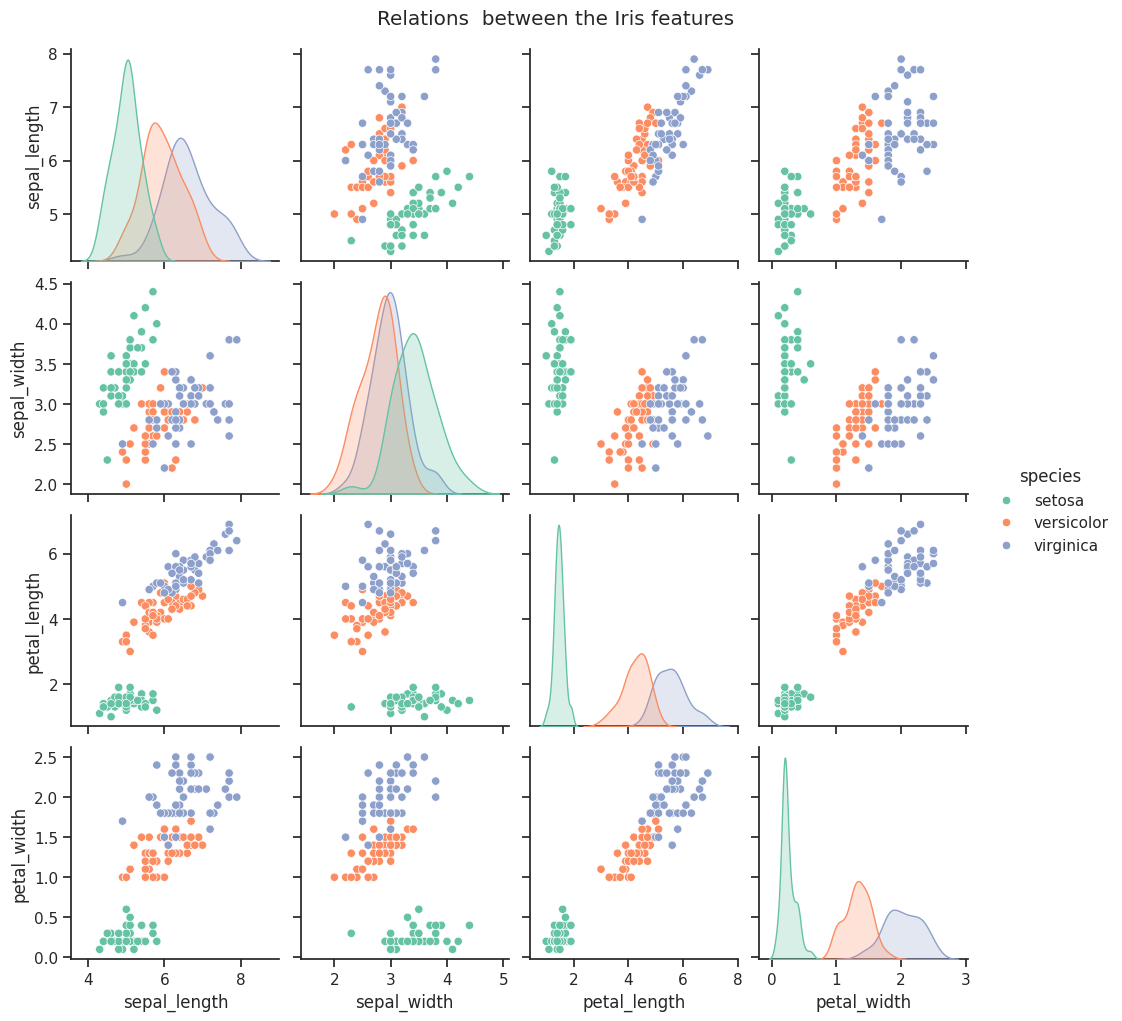

In [11]:
sns.set_theme(style="ticks")
sns.pairplot(df, hue = "species", palette = "Set2")
plt.suptitle("Relations  between the Iris features", y=1.02)
plt.show()

# Interpretation

The pairplot reveals that setosa (green) stands out instantly from the others due to its significantly smaller petals, making it highly distinct and easy to classify. In contrast, versicolor (orange) and virginica (blue) share very similar traits and their data points overlap, making them harder to separate. Overall, petal dimensions (length and width) provide much cleaner, more informative boundaries for differentiating the three species than sepal measurements. 



# Preprocessing_Feature scaling & encoding

In [12]:
# Separate features and target
X = df.drop(columns=['species'])
y = df['species']

# Encode target labels  (setosa=0, versicolor=1, virginica=2)
le = LabelEncoder()
y_enc = le.fit_transform(y)
print('Classes:', le.classes_)

# Train / Test split  (80 / 20, stratified so each class is balanced)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.20, random_state=42, stratify=y_enc
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

# Feature scaling  (logistic regression is sensitive to scale)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_sc  = scaler.transform(X_test)        # transform test with train stats

Classes: ['setosa' 'versicolor' 'virginica']
Train: (117, 4)  |  Test: (30, 4)


In [13]:
# Train
lr = LogisticRegression(max_iter = 300, random_state = 42)
lr.fit(X_train_sc, y_train)

#Predict
y_pred_lr = lr.predict(X_test_sc)

# Core metrics
print('=== Logistic Regression ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_lr, average="weighted"):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_lr, average="weighted"):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_lr, average="weighted"):.4f}')
print()
print('--- Per-class report ---')
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

=== Logistic Regression ===
Accuracy : 0.9333
Precision: 0.9333
Recall   : 0.9333
F1 Score : 0.9333

--- Per-class report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



# Confusion Matrix

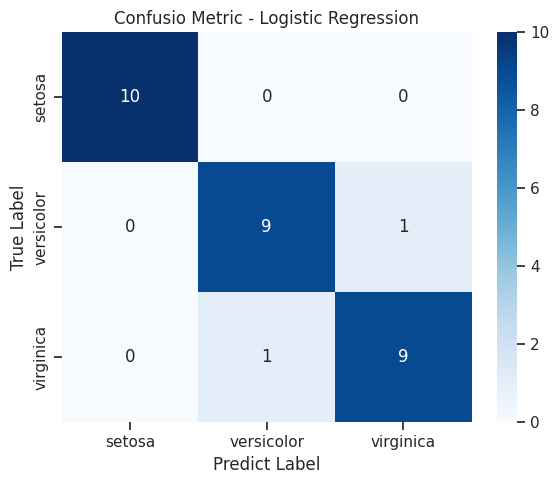

In [14]:
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot = True, fmt = 'd', cmap='Blues',
    xticklabels = le.classes_, yticklabels = le.classes_
)
plt.title('Confusio Metric - Logistic Regression')
plt.ylabel('True Label')
plt.xlabel("Predict Label")
plt.tight_layout()
plt.show()


## Step 4 · ROC Curve (One-vs-Rest, multi-class)

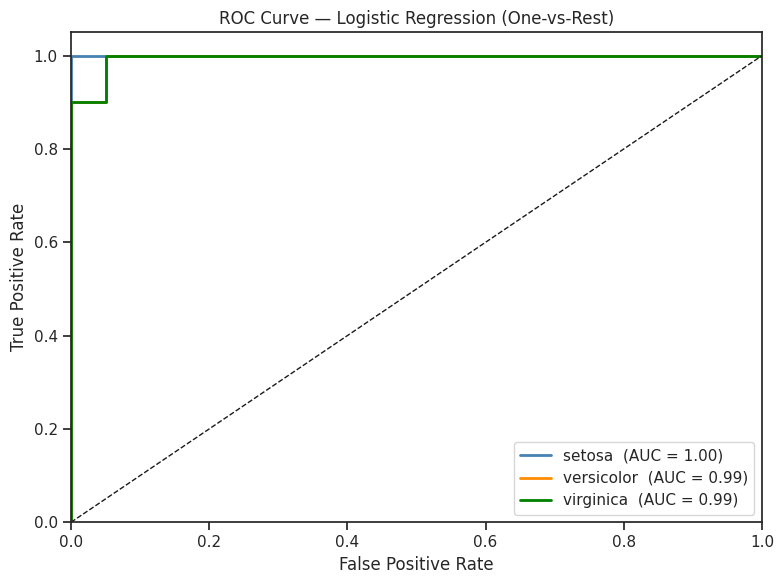

In [15]:
# Binarize labels for One-vs-Rest ROC
y_test_bin  = label_binarize(y_test,  classes=[0, 1, 2])
y_score_lr  = lr.predict_proba(X_test_sc)

plt.figure(figsize=(8, 6))
colors = ['steelblue', 'darkorange', 'green']

for i, (cls, col) in enumerate(zip(le.classes_, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_lr[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=col, lw=2,
             label=f'{cls}  (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression (One-vs-Rest)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Compare with Random  Forest & SVM

In [16]:
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=300, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF kernel)'   : SVC(kernel='rbf', probability=True, random_state=42),
}
results = []
for name, clf in classifiers.items():
    clf.fit(X_train_sc, y_train)
    y_pred = clf.predict(X_test_sc)
    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, average='weighted'), 4),
        'Recall'   : round(recall_score(y_test, y_pred, average='weighted'), 4),
        'F1'       : round(f1_score(y_test, y_pred, average='weighted'), 4),
    })

results_df = pd.DataFrame(results).set_index('Model')
display(results_df)

,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.9333,0.9333,0.9333,0.9333
Random Forest,0.9667,0.9697,0.9667,0.9666
SVM (RBF kernel),0.9667,0.9697,0.9667,0.9666


# Visual comparison of all models

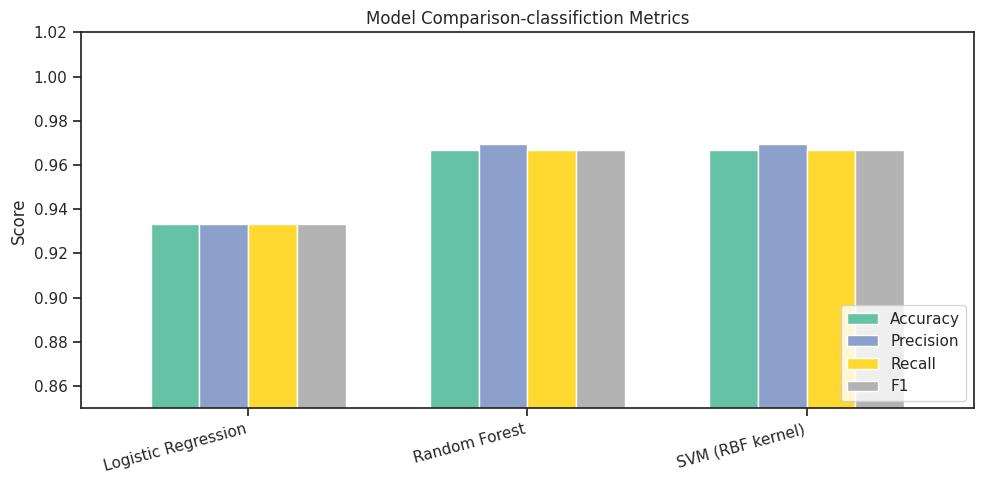

In [17]:
ax = results_df.plot(
    kind = 'bar', figsize=(10,5), colormap='Set2',
    edgecolor = "white", width=0.7
)
ax.set_title("Model Comparison-classifiction Metrics")
ax.set_xlabel("")
ax.set_ylabel('Score')
ax.set_ylim(0.85,1.02)
ax.legend(loc="lower right")
plt.xticks(rotation=15, ha= "right")
plt.tight_layout()
plt.show()

---
## Interpretation Guide

| Metric | What it tells you |
|--------|-------------------|
| **Accuracy** | Overall fraction of correct predictions. Good baseline on balanced datasets like Iris. |
| **Precision** | Of all instances *predicted* as class X, how many actually are X? High precision = few false positives. |
| **Recall** | Of all *true* instances of class X, how many did we catch? High recall = few false negatives. |
| **F1 Score** | Harmonic mean of precision & recall. Balances both. Use when classes matter equally. |
| **ROC / AUC** | Probability that the model ranks a random positive higher than a random negative. AUC=1.0 is perfect. |

**Expected findings on Iris:**
- All three models should score > 95 % accuracy.
- *Setosa* is always perfectly classified (linearly separable).
- *Versicolor* vs *Virginica* is where models differ, check the confusion matrix. 
- SVM and Random Forest often edge out Logistic Regression slightly on this dataset.
